In [22]:
import sys,os,re,argparse,glob
import pandas as pd
from scipy.io import loadmat
from pathlib import Path
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

import numpy as np


In [23]:
ROOT = Path('/home/tntiniak/Work/observatory_benchmark')
PHYSICELL_DIR = ROOT / 'PhysiCell' / 'results' / 'mechanics_external_impulse'
OUTPUT_FILENAME = 'physicell_mechanics_external_impulse_data.csv'


In [24]:
for folder in PHYSICELL_DIR.glob('dt_*'):
    dt_value = float(folder.name.split('_')[1])

    records = []
    for xml_path in sorted(folder.glob('output*.xml')):
        root = ET.parse(xml_path).getroot()
        current_time = float(root.findtext('.//current_time'))
        mat_name = root.findtext('.//simplified_data/filename')
        if mat_name is None:
            raise ValueError(f'No cell data filename found in {xml_path}')

        cells = loadmat(folder / mat_name)['cells']
        cell_x = cells[1,0]
        cell_velocity = cells[17,0]

        cell_migration_speed = cells[50,0]
        cell_mvx = cells[57,0]
        # 'id','x','y','z','velocity','is_motile','migration_speed','mvx','mvy','mvz','dt'

        records.append({
            'dt': current_time,
            'x': cell_x,
            'velocity': cell_velocity,
            'migration_speed': cell_migration_speed,
            'mvx': cell_mvx,
            # 'velocity_um_per_min': velocity
        })
    frame = pd.DataFrame.from_records(records).sort_values('dt').reset_index(drop=True)
    frame.to_csv(folder / OUTPUT_FILENAME, index=False)

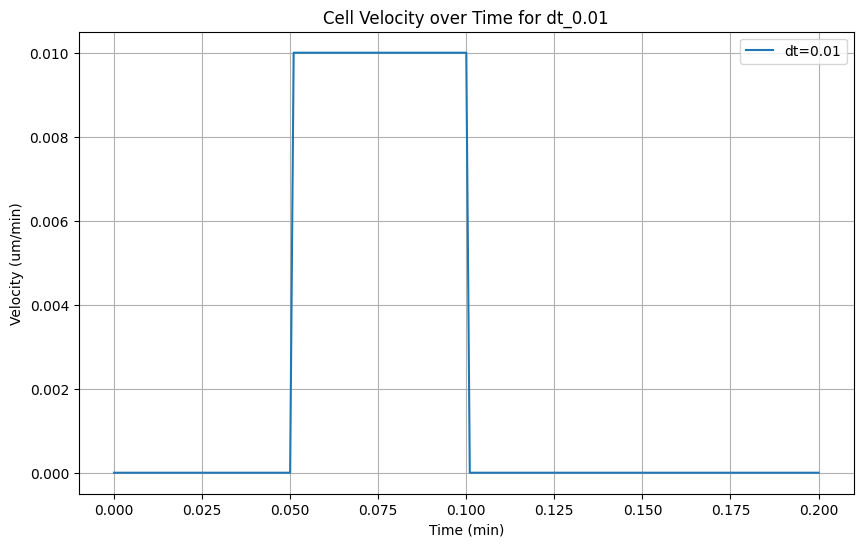

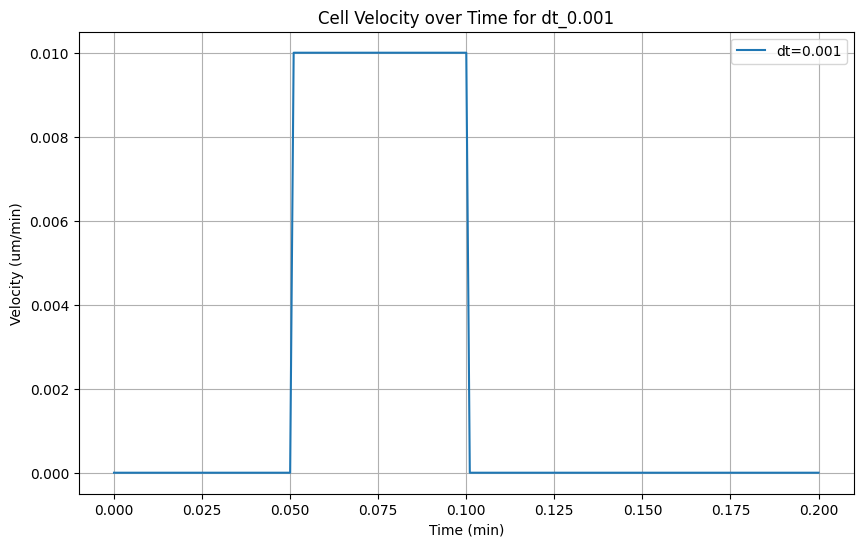

In [25]:
# plot velocities for each folder with different dt
for folder in PHYSICELL_DIR.glob('dt_*'):
    df = pd.read_csv(folder / OUTPUT_FILENAME)
    plt.figure(figsize=(10, 6))
    plt.plot(df['dt'], df['mvx'], label=f"dt={folder.name.split('_')[1]}")
    plt.xlabel('Time (min)')
    plt.ylabel('Velocity (um/min)')
    plt.title(f'Cell Velocity over Time for {folder.name}')
    plt.legend()
    plt.grid()
    plt.show()
    plt.savefig(folder / f'velocity_plot_{folder.name}.png')
    
    plt.close()

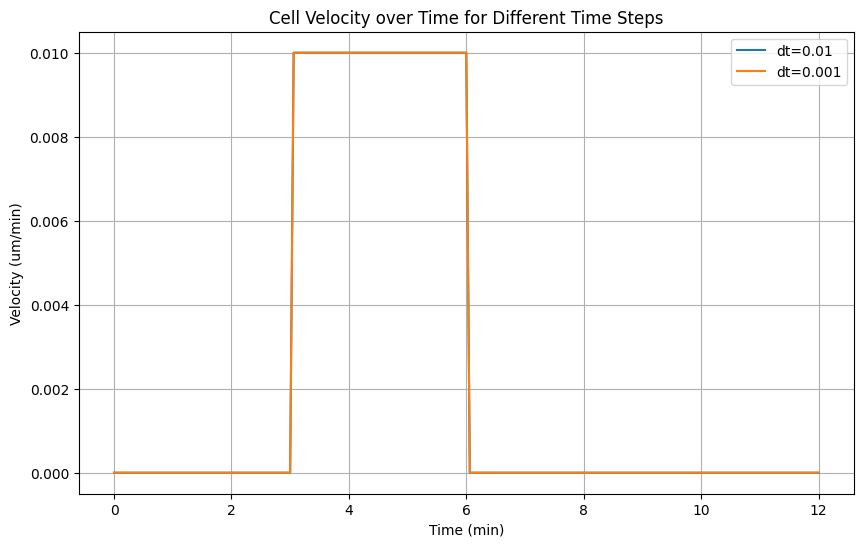

In [26]:
# plot velocities in same figure for comparison
plt.figure(figsize=(10, 6))
for folder in PHYSICELL_DIR.glob('dt_*'):
    df = pd.read_csv(folder / OUTPUT_FILENAME)
    plt.plot(df['dt']*60, df['mvx'], label=f"dt={folder.name.split('_')[1]}")
    
plt.xlabel('Time (min)')
plt.ylabel('Velocity (um/min)')
plt.title('Cell Velocity over Time for Different Time Steps')
plt.legend()
plt.grid()
plt.show()


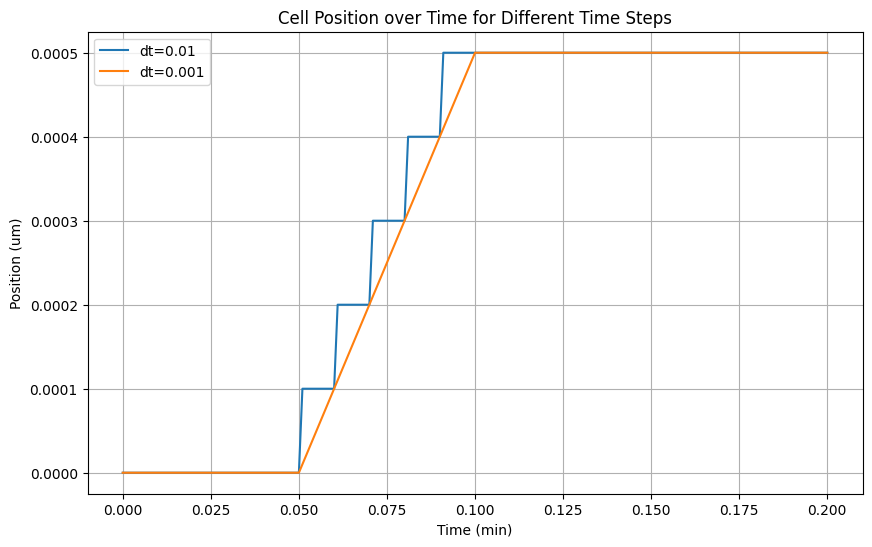

In [27]:
# plot positions in same figure for comparison
plt.figure(figsize=(10, 6))
for folder in PHYSICELL_DIR.glob('dt_*'):
    df = pd.read_csv(folder / OUTPUT_FILENAME)
    plt.plot(df['dt'], df['x'], label=f"dt={folder.name.split('_')[1]}")
    # break
plt.xlabel('Time (min)')
plt.ylabel('Position (um)')
plt.title('Cell Position over Time for Different Time Steps')
plt.legend()
plt.grid()
plt.show()
